This is a redo of the MIT Deep Learning course @ https://colab.research.google.com/drive/1IDS6F8nkfszgqm54EvvnCPaUBXGgsZzf?usp=sharing

You can get the full course at https://ocw.mit.edu/courses/15-773-hands-on-deep-learning-spring-2024

In this notebook I adapted their notebook from the link above using pytorch, Just a test nothing mcuh 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchinfo import summary
import matplotlib.pyplot as plt

In [2]:
train_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)

In [3]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [4]:
test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

In [5]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [6]:
print(train_data.data.shape)
print(train_data.targets.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])


In [7]:
print(test_data.data.shape)
print(test_data.targets.shape)

torch.Size([10000, 28, 28])
torch.Size([10000])


In [8]:
x_train = train_data.data
y_train = train_data.targets

In [9]:
x_test = test_data.data
y_test = test_data.targets

In [10]:
x_test.shape

torch.Size([10000, 28, 28])

In [11]:
train, val = random_split(train_data, [0.8, 0.2], generator=torch.Generator().manual_seed(42))

In [12]:
type(train)

torch.utils.data.dataset.Subset

In [13]:
train[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1529, 0.2353, 0.2000,
           0.2235, 0.1961, 0.2157, 0.2078, 0.1961, 0.1922, 0.1647, 0.1725,
           0.1804, 0.1843, 0.2353, 0.0431],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0078, 0.0000, 0.5216, 0.6196, 0.5922,
           0.7529, 0.7725, 0.8118, 0.7882, 

## In using datasets, tensor datasets autonatically gets the x and y. so no need to be doing x_train...


In [14]:
# OK, let's look at the first 10 rows of the dependent variable  y .

[train[index][1] for index in range(10)]

[9, 2, 5, 0, 5, 1, 3, 5, 0, 1]

In [15]:
# What do these numbers mean?
# Let's create a little Python list so that we can go from numbers to descriptions easily.

labels = [label for label in train_data.classes]

In [16]:
labels

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [17]:
# Given a number, the description is now a simple look-up. Let's see what the very first training example is about.

labels[train[0][1]]

'Ankle boot'

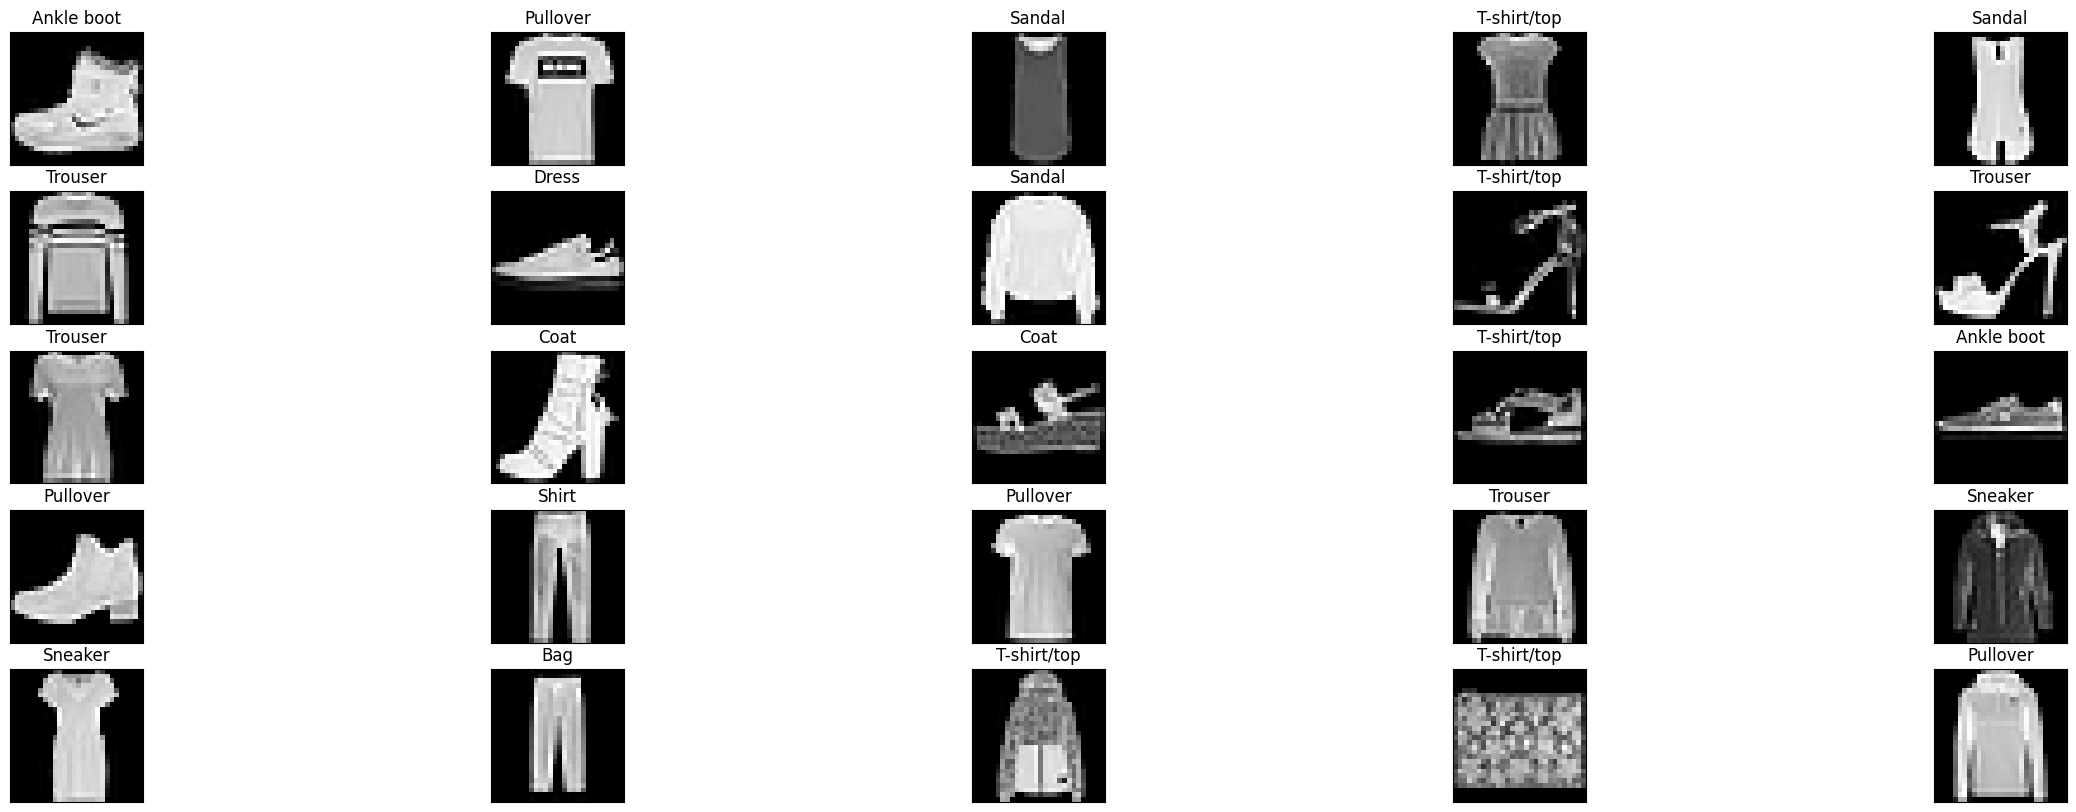

In [18]:
fig, ax = plt.subplots(5, 5, figsize=(30, 10))
for i in range(25):
  axc = ax[i//5, i%5]
  axc.imshow(x_train[i], cmap="gray")
  axc.set_title(f"{labels[train[i][1]]}")
  axc.set_xticks([])
  axc.set_yticks([])

NN Model

Data Prep(Already done this when converting to tensor)

Tip: NNs learn best when each independent variable is in a small range. So, standardize them by either

subtracting the mean and dividing by the standard deviation or
if they are in a guaranteed range, just divide by the max value.
The inputs here range from 0 to 255. Let's normalize to the 0-1 range by dividing everything by 255.

## Loading the dataset(Forgot)

In [19]:
train_loader = DataLoader(train, batch_size=64, shuffle=True)
val_loader = DataLoader(val, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [20]:
# freestyling to check train labels

[labels[num] for num in next(iter(train_loader))[1]]

['Sandal',
 'Pullover',
 'Sneaker',
 'Bag',
 'Pullover',
 'Sneaker',
 'Sneaker',
 'Dress',
 'T-shirt/top',
 'Pullover',
 'Shirt',
 'Bag',
 'T-shirt/top',
 'Dress',
 'Trouser',
 'Trouser',
 'Dress',
 'Sneaker',
 'Trouser',
 'Trouser',
 'Sneaker',
 'Ankle boot',
 'Shirt',
 'Pullover',
 'Bag',
 'T-shirt/top',
 'T-shirt/top',
 'Trouser',
 'Pullover',
 'Trouser',
 'Dress',
 'Bag',
 'Coat',
 'Ankle boot',
 'Sneaker',
 'Bag',
 'T-shirt/top',
 'Dress',
 'Sneaker',
 'Sandal',
 'Sneaker',
 'Ankle boot',
 'Bag',
 'Trouser',
 'Shirt',
 'Bag',
 'Sneaker',
 'Bag',
 'Pullover',
 'Ankle boot',
 'T-shirt/top',
 'Dress',
 'Shirt',
 'Shirt',
 'Pullover',
 'Ankle boot',
 'T-shirt/top',
 'Bag',
 'Trouser',
 'Coat',
 'Sandal',
 'Bag',
 'Coat',
 'Trouser']

## Defining the model

The input will be 28 x 28 matrices of numbers. These will have to be flattened into a loooong vector and then fed to the next layer.
We will use just a single hidden layer.
Since this is a multi-class classification problem (e.g., we need to predict one of 10 clothing categories), the output layer has to produce a 10-element vector of probabilities that sum up to 1.0 => we will use the softmax layer.

In [21]:
model = torch.nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=(28*28), out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=10),
    nn.LogSoftmax(dim=1)
)

In [22]:
summary(model)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            200,960
├─ReLU: 1-3                              --
├─Linear: 1-4                            2,570
├─LogSoftmax: 1-5                        --
Total params: 203,530
Trainable params: 203,530
Non-trainable params: 0

In [23]:
# Let's hand-calculate the number of parameters to verify.

(784 * 256 + 256) + (256 * 10 + 10)

203530

## Set Optimization Parameters

Now that the model is defined, we need to tell Keras three things:

What loss function to use
Which optimizer to use - we will again use Adam which is an excellent set-and-forget choice
What metrics you want Keras to report out - in classification problems like this one, Accuracy is usually the metric you want to see.

Since our output variable is categorical with 10 levels, we will select the sparse_categorical_crossentropy loss function. Recall this slide from the lecture:

In [24]:
loss_fun = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Let's define a train Function

In [25]:
def train_epoch(model, train_loader, loss_fun, optimizer, device='cpu'):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # zero gradients
        optimizer.zero_grad()

        # foward pass
        outputs = model(images)
        loss = loss_fun(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # tracking the metrics
        running_loss += loss.item()         # loss.item() converts tensor to Python float
        max_value, predicted = torch.max(outputs, 1)        # Example: If outputs = [0.1, 0.7, 0.2,...], predicted = 1
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc





Define a valiadtion function 

In [26]:
def val_epoch(model, val_loader, loss_fun, device = 'cpu'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():       # Disable gradient computation
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fun(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(val_loader)
        epoch_acc = correct / total

        return epoch_loss, epoch_acc




In [30]:
epochs = 20


# storing the train info
train_losses = []
train_accuracy = []
val_losses = []
val_accuracy = []

print("Starting training...")
print("=" * 50)

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, loss_fun, optimizer)
    val_loss, val_acc = val_epoch(model, val_loader, loss_fun)

    train_losses.append(train_loss)
    train_accuracy.append(train_acc)
    val_losses.append(val_loss)
    val_accuracy.append(val_acc)

# Print progress
print(f"Epoch [{epoch+1}/{epochs}]")
print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
print(f"  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")
print("-" * 40)

Starting training...
Epoch [20/20]
  Train Loss: 0.0926, Train Acc: 0.9665
  Val Loss:   0.4373, Val Acc:   0.8888
----------------------------------------


## Evaluating the Test

In [31]:
test_loss, test_acc = val_epoch(model, test_loader, loss_fun)
print("\n" + "=" * 50)
print("FINAL RESULTS")
print("=" * 50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


FINAL RESULTS
Test Loss: 0.4697
Test Accuracy: 0.8847


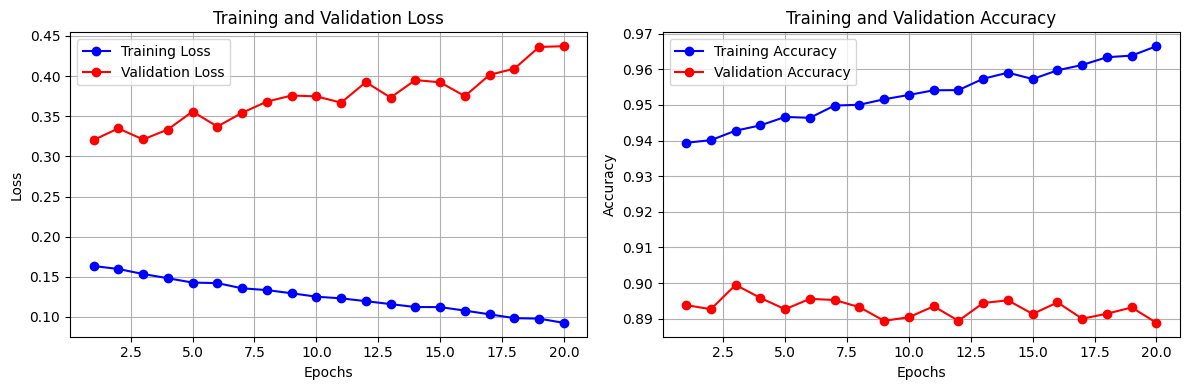

In [32]:
# Plot loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, 'b-o', label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, 'r-o', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracy, 'b-o', label='Training Accuracy')
plt.plot(range(1, epochs + 1), val_accuracy, 'r-o', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()